In [1]:
import h5py
import matplotlib.pyplot as plt
import torch

In [3]:
f = h5py.File("data/pong_frames.h5", "r")

In [7]:
frame = f['frames'][0:100]

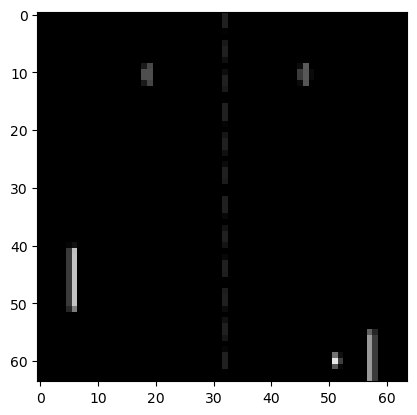

In [15]:
plt.imshow(frame[2])

In [20]:
torch.tensor(frame[2]).flatten()

tensor([0, 0, 0,  ..., 0, 0, 0], dtype=torch.uint8)

In [4]:
frames = f["frames"][:]

In [ ]:
frames_trch = torch.tensor(frames)

In [8]:
frames_trch.shape

torch.Size([108034, 64, 64, 3])

In [9]:
frames_trch = frames_trch.permute(0, 3, 1, 2)
frames_trch.shape

torch.Size([108034, 3, 64, 64])

In [10]:
frames_trch = frames_trch.float() / 255.0

In [28]:
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import Adam

In [20]:
frames_trch.shape, frames_trch.size(), len(frames_trch)

(torch.Size([108034, 3, 64, 64]), torch.Size([108034, 3, 64, 64]), 108034)

In [21]:
class PongDataset(Dataset):
    def __init__(self, data):
        super().__init__()

        self.data = data

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index], self.data[index + 1]


dataset = PongDataset(frames_trch)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [ ]:
class NextFrameMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_in = nn.Linear(12288, 256)
        self.relu = nn.ReLU()
        self.linear_out = nn.Linear(256, 12288)

    def forward(self, x):
        batch_size = x.shape[0]
        x = x.view(batch_size, -1)   # flatten: (B, 3, 64, 64) -> (B, 12288)
        x = self.linear_in(x)
        x = self.relu(x)
        x = self.linear_out(x)
        x = x.view(batch_size, 3, 64, 64)  # unflatten back
        return x

In [ ]:
model = NextFrameMLP()
optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = nn.SmoothL1Loss()

In [ ]:
from IPython.display import display, clear_output
import numpy as np
import time

NUM_EPOCHS = 10
losses = []
epoch_losses = []
step = 0

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
display_handle = display(fig, display_id=True)

for epoch in range(NUM_EPOCHS):
    batch_losses = []
    for batch_input, batch_target in loader:
        pred = model(batch_input)
        loss = loss_fn(pred, batch_target)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        batch_losses.append(loss.item())
        step += 1

        # Update plots every 50 steps
        if step % 50 == 0:
            for ax in axes:
                ax.clear()

            # Plot 1: Loss per step
            axes[0].plot(losses, linewidth=0.5, alpha=0.6, color='steelblue')
            # Smoothed line (rolling avg)
            if len(losses) > 20:
                smoothed = np.convolve(losses, np.ones(20)/20, mode='valid')
                axes[0].plot(range(19, 19+len(smoothed)), smoothed, color='darkblue', linewidth=2)
            axes[0].set_xlabel('Step')
            axes[0].set_ylabel('Loss')
            axes[0].set_title(f'Training Loss (step {step})')
            axes[0].grid(True, alpha=0.3)

            # Plot 2: Epoch avg loss
            if epoch_losses:
                axes[1].plot(range(1, len(epoch_losses)+1), epoch_losses, 'o-', color='coral', linewidth=2)
                axes[1].set_xlabel('Epoch')
                axes[1].set_ylabel('Avg Loss')
                axes[1].set_title('Loss per Epoch')
                axes[1].grid(True, alpha=0.3)
            else:
                axes[1].set_title('Loss per Epoch (waiting...)')
                axes[1].grid(True, alpha=0.3)

            # Plot 3: Sample prediction vs target
            with torch.no_grad():
                sample_in = batch_input[0:1]
                sample_pred = model(sample_in).clamp(0, 1)
                sample_target = batch_target[0]

            pred_img = sample_pred[0].permute(1, 2, 0).cpu().numpy()
            target_img = sample_target.permute(1, 2, 0).cpu().numpy()
            comparison = np.concatenate([target_img, pred_img], axis=1)
            axes[2].imshow(comparison)
            axes[2].set_title('Target (left) vs Prediction (right)')
            axes[2].axis('off')

            fig.tight_layout()
            display_handle.update(fig)

    avg_epoch_loss = np.mean(batch_losses)
    epoch_losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} — avg loss: {avg_epoch_loss:.6f}")

plt.close(fig)
print("Training complete!")